# CIC-IDS-2017 Pipeline
Self-contained end-to-end pipeline for training the MCL-FWA-BILSTM hybrid model on the CIC-IDS-2017 dataset.

**Stages:**
1. Architecture definitions (MCL, CustomBiLSTM, FWA, Extractor)
2. Training utilities (TrainConfig, train_extractor)
3. Classifier utilities (TreeConfig, fit_rf, fit_xgb, evaluate)
4. Data preprocessing (8 CSV files → 160k sample → 80/20 split → zero-pad to 120 → 10×12 tensor)
5. Phase 1: Train DL feature extractor
6. Phase 2: Train Random Forest & XGBoost on extracted features
7. Evaluate and compare results

> **Note on high accuracy:** CIC-IDS-2017 is a lab-generated benchmark. Scores of ~0.99 are expected and well-documented in literature due to the deterministic nature of lab-captured attack flows.

## 1. Imports

In [1]:
from __future__ import annotations

import glob, os
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from xgboost import XGBClassifier

print(f"PyTorch: {torch.__version__}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")

PyTorch: 2.11.0+cu128
Device : cuda


## 2. Architecture — Layer: MCL (CNN with Prediction-Error-Filter Constraint)

Paper §F, Algorithm 1, Eqs 1–4.  
Input: `(N, 10, 12)` spatial tensor. Output: `Wc` feature vector `(N, 56)`.

In [2]:
class MCL(nn.Module):
    def __init__(self, in_features: int = 120, n_filters: int = 10, out_features: int = 56) -> None:
        super().__init__()
        self.mcl_conv = nn.Conv2d(1, n_filters, kernel_size=3, padding=1, bias=False)
        self.conv_stack = nn.Sequential(
            nn.Conv2d(n_filters, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.flatten_dim = 16 * 5 * 6
        self.project = nn.Linear(self.flatten_dim, out_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = x.unsqueeze(1)
        h = torch.tanh(self.mcl_conv(h))
        h = self.conv_stack(h)
        h = h.flatten(1)
        return self.project(h)

    @torch.no_grad()
    def apply_mcl_constraint(self) -> None:
        """Re-project MCL conv weights to satisfy the zero-sum prediction-error-filter constraint."""
        w = self.mcl_conv.weight.data
        w_flat = w.view(w.shape[0], w.shape[1], -1)
        k = w_flat.shape[-1]
        center = k // 2
        idx = [i for i in range(k) if i != center]
        idx_t = torch.tensor(idx, device=w.device)
        others = w_flat.index_select(-1, idx_t)
        denom = others.abs().sum(dim=-1, keepdim=True).clamp_min(1e-8)
        normalized = others / denom
        w_flat.index_copy_(-1, idx_t, normalized)
        w_flat[..., center] = -normalized.sum(dim=-1)
        w.copy_(w_flat.view(w.shape))

## 3. Architecture — Layer: CustomBiLSTM (Fused CNN+RNN Cell)

In [3]:
class CustomRNNCell(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, wc_size: int):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_x = nn.Linear(input_size, hidden_size, bias=False)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=True)
        self.W_c_proj = nn.Linear(wc_size, hidden_size, bias=False)

    def forward(self, x_t: torch.Tensor, h_prev: torch.Tensor, w_c: torch.Tensor) -> torch.Tensor:
        return torch.tanh(self.W_x(x_t) + self.U_c(h_prev) + self.W_c_proj(w_c))


class CustomBiLSTM(nn.Module):
    def __init__(self, input_size: int = 12, hidden_size: int = 64, wc_size: int = 56):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell_fwd = CustomRNNCell(input_size, hidden_size, wc_size)
        self.cell_bwd = CustomRNNCell(input_size, hidden_size, wc_size)

    def forward(self, x: torch.Tensor, w_c: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        N, T, _ = x.size()
        device = x.device
        h_fwd = torch.zeros(N, self.hidden_size, device=device)
        h_bwd = torch.zeros(N, self.hidden_size, device=device)
        out_fwd, out_bwd = [], []
        for t in range(T):
            h_fwd = self.cell_fwd(x[:, t, :], h_fwd, w_c)
            out_fwd.append(h_fwd)
        for t in reversed(range(T)):
            h_bwd = self.cell_bwd(x[:, t, :], h_bwd, w_c)
            out_bwd.insert(0, h_bwd)
        out_fwd = torch.stack(out_fwd, dim=1)
        out_bwd = torch.stack(out_bwd, dim=1)
        out = torch.cat([out_fwd, out_bwd], dim=-1)
        fbl = torch.cat([out_fwd[:, -1, :], out_bwd[:, 0, :]], dim=-1)
        return out, fbl

## 4. Architecture — Layer: FWA (Feature-Weighted Attention)

Paper Algorithm 2, lines 395–405; Eqs 1–2.

In [4]:
class FWA(nn.Module):
    """
    score_t = v^T · tanh(W1·h_t + W2·Wc + b)
    FA_t    = softmax_t(score_t)
    FAT     = Σ_t FA_t · h_t
    Fe      = concat(FBL, FAT)
    """
    def __init__(self, hidden_dim: int, wc_dim: int, attn_dim: int | None = None):
        super().__init__()
        if attn_dim is None:
            attn_dim = hidden_dim
        self.W1 = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W2 = nn.Linear(wc_dim, attn_dim, bias=True)
        self.v  = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, h, wc, fbl):
        q      = self.W2(wc).unsqueeze(1)
        k      = self.W1(h)
        scores = self.v(torch.tanh(k + q)).squeeze(-1)
        fa     = torch.softmax(scores, dim=-1)
        fat    = torch.bmm(fa.unsqueeze(1), h).squeeze(1)
        fe     = torch.cat([fbl, fat], dim=-1)
        return fe, fa

## 5. Architecture — Extractor & ExtractorWithHead

In [5]:
class Extractor(nn.Module):
    def __init__(self, in_features=120, mcl_filters=10, wc_dim=56, lstm_hidden=64, attn_dim=None):
        super().__init__()
        self.in_features = in_features
        self.mcl    = MCL(in_features=in_features, n_filters=mcl_filters, out_features=wc_dim)
        self.bilstm = CustomBiLSTM(input_size=12, hidden_size=lstm_hidden, wc_size=wc_dim)
        self.fwa    = FWA(hidden_dim=2 * lstm_hidden, wc_dim=wc_dim, attn_dim=attn_dim)
        self.feature_dim = 4 * lstm_hidden

    def forward(self, x):
        wc     = self.mcl(x)
        h, fbl = self.bilstm(x, wc)
        fe, fa = self.fwa(h, wc, fbl)
        return fe, {"wc": wc, "fbl": fbl, "fa": fa}

    def apply_mcl_constraint(self):
        self.mcl.apply_mcl_constraint()


class ExtractorWithHead(nn.Module):
    def __init__(self, extractor: Extractor, n_classes: int):
        super().__init__()
        self.extractor = extractor
        self.head = nn.Linear(extractor.feature_dim, n_classes)

    def forward(self, x):
        fe, _ = self.extractor(x)
        return self.head(fe), fe

    def apply_mcl_constraint(self):
        self.extractor.apply_mcl_constraint()

## 6. Training Utilities

In [6]:
@dataclass
class TrainConfig:
    epochs:                  int   = 100
    batch_size:              int   = 256
    lr:                      float = 1e-3
    weight_decay:            float = 0.0
    device:                  str   = "cuda" if torch.cuda.is_available() else "cpu"
    target:                  str   = "binary"
    log_every:               int   = 0
    seed:                    int   = 0
    extractor_kwargs:        dict  = field(default_factory=dict)
    target_val_acc:          float = 0.90
    early_stopping_patience: int   = 5


def _make_loader(X, y, cfg, shuffle):
    ds = TensorDataset(X, y.long())
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=cfg.device.startswith("cuda"))


@torch.no_grad()
def _evaluate_loop(model, loader, loss_fn, device):
    model.eval()
    running, seen, correct = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        logits, _ = model(xb)
        loss = loss_fn(logits, yb)
        bs = yb.size(0)
        running += loss.item() * bs; seen += bs
        correct += (logits.argmax(dim=-1) == yb).sum().item()
    return {"val_loss": running / seen, "val_acc": correct / seen}


def train_extractor(X_train, y_train, cfg=None, X_val=None, y_val=None):
    cfg = cfg or TrainConfig()
    torch.manual_seed(cfg.seed)
    n_classes = int(y_train.max().item()) + 1
    extractor = Extractor(in_features=X_train.shape[1], **cfg.extractor_kwargs)
    model     = ExtractorWithHead(extractor, n_classes=n_classes).to(cfg.device)
    if cfg.device.startswith("cuda") and torch.cuda.device_count() > 1:
        model = torch.nn.DataParallel(model)
    opt     = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    train_loader = _make_loader(X_train, y_train, cfg, shuffle=True)
    val_loader   = _make_loader(X_val, y_val, cfg, shuffle=False) if X_val is not None else None
    history, best_val_loss, patience_counter = [], float("inf"), 0

    for epoch in range(cfg.epochs):
        model.train()
        running, seen, correct = 0.0, 0, 0
        for step, (xb, yb) in enumerate(train_loader):
            xb, yb = xb.to(cfg.device, non_blocking=True), yb.to(cfg.device, non_blocking=True)
            logits, _ = model(xb)
            loss = loss_fn(logits, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            underlying = model.module if isinstance(model, torch.nn.DataParallel) else model
            underlying.apply_mcl_constraint()
            bs = yb.size(0)
            running += loss.item() * bs; seen += bs
            correct += (logits.argmax(dim=-1) == yb).sum().item()
            if cfg.log_every and (step + 1) % cfg.log_every == 0:
                print(f"epoch {epoch} step {step+1} loss {running/seen:.4f}")
        row = {"epoch": epoch, "train_loss": running / seen, "train_acc": correct / seen}
        if val_loader is not None:
            val_metrics = _evaluate_loop(model, val_loader, loss_fn, cfg.device)
            row.update(val_metrics)
        history.append(row)
        if cfg.log_every: print(row)
        if val_loader is not None:
            val_acc, val_loss = val_metrics["val_acc"], val_metrics["val_loss"]
            if val_acc >= cfg.target_val_acc:
                print(f"Reached target validation accuracy: {val_acc:.4f} >= {cfg.target_val_acc}. Stopping.")
                break
            if val_loss < best_val_loss:
                best_val_loss = val_loss; patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= cfg.early_stopping_patience:
                    print(f"Validation loss did not improve for {cfg.early_stopping_patience} epochs.")
    return extractor, history


@torch.no_grad()
def extract_features(extractor, X, batch_size=512, device=None):
    device = device or next(extractor.parameters()).device.type
    extractor.eval()
    out = []
    for i in range(0, X.shape[0], batch_size):
        xb = X[i : i + batch_size].to(device, non_blocking=True)
        fe, _ = extractor(xb)
        out.append(fe.cpu())
    return torch.cat(out, dim=0)

## 7. Classifier Utilities (Random Forest & XGBoost)

In [7]:
@dataclass
class TreeConfig:
    n_estimators: int       = 200
    max_depth:    int | None = None
    n_jobs:       int       = -1
    random_state: int       = 0
    extra:        dict      = field(default_factory=dict)


def fit_rf(Fe_train, y_train, cfg=None):
    cfg = cfg or TreeConfig()
    clf = RandomForestClassifier(
        n_estimators=cfg.n_estimators, max_depth=cfg.max_depth,
        n_jobs=cfg.n_jobs, class_weight="balanced",
        random_state=cfg.random_state, **cfg.extra,
    )
    clf.fit(Fe_train, y_train)
    return clf


def fit_xgb(Fe_train, y_train, cfg=None):
    cfg = cfg or TreeConfig()
    clf = XGBClassifier(
        n_estimators=cfg.n_estimators, max_depth=cfg.max_depth,
        n_jobs=cfg.n_jobs, random_state=cfg.random_state,
        eval_metric="mlogloss", **cfg.extra,
    )
    clf.fit(Fe_train, y_train)
    return clf


def evaluate(clf, Fe, y):
    y_pred = clf.predict(Fe)
    avg = "binary" if len(np.unique(y)) == 2 else "macro"
    return {
        "accuracy":         accuracy_score(y, y_pred),
        "precision":        precision_score(y, y_pred, average=avg, zero_division=0),
        "recall":           recall_score(y, y_pred, average=avg, zero_division=0),
        "f1":               f1_score(y, y_pred, average=avg, zero_division=0),
        "confusion_matrix": confusion_matrix(y, y_pred).tolist(),
        "report":           classification_report(y, y_pred, zero_division=0),
    }

## 8. Data Preprocessing — CIC-IDS-2017

- Merges all 8 CSV files from the dataset directory
- Randomly samples **160,000 rows** (ensures ~500 steps/epoch at batch size 256, covers all attack types across the week)
- Drops duplicate columns and handles `Infinity`/`NaN` values
- Splits **80/20 train/test FIRST** to prevent data leakage
- Applies `StandardScaler` fitted **only on train set**, transforms test with same parameters
- Zero-pads features from 77 → 120, reshapes to `(N, 10, 12)`

In [8]:
from transformers.models.bert_generation import tokenization_bert_generation
def load_raw_cic(data_dir):
    data_dir = Path(data_dir)
    csv_files = glob.glob(str(data_dir / "*.csv"))
    if not csv_files:
        raise ValueError(f"No CSV files found in {data_dir}")
    print(f"Found {len(csv_files)} CSV files. Loading...")
    dfs = []
    for f in csv_files:
        print(f"  Loading {os.path.basename(f)}...")
        dfs.append(pd.read_csv(f))
    merged = pd.concat(dfs, ignore_index=True)
    merged.columns = merged.columns.str.strip()
    return merged


def preprocess_cic(df):
    print(f"Initial shape: {df.shape}")
    # Sample to 160,000 rows → 128,000 train at 80/20 → 500 steps/epoch at batch_size=256
    target_size = 500000
    if len(df) > target_size:
        print(f"Sampling {target_size} rows from {len(df)}...")
        df = df.sample(n=target_size, random_state=42).reset_index(drop=True)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)
    label_col = "Label" if "Label" in df.columns else "label"
    y_bin = (df[label_col] != "BENIGN").astype(np.int64).to_numpy()
    df = df.drop(columns=[label_col])
    feature_names = df.columns.tolist()
    X = df.to_numpy(dtype=np.float32)
    print(f"Features shape: {X.shape}")
    # Split BEFORE scaling to prevent leakage
    print("Splitting 80/20...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
    )
    print("Scaling (fit on train only)...")
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test  = scaler.transform(X_test).astype(np.float32)
    # Zero-pad to 120 features
    n_feat = X_train.shape[1]
    if n_feat < 120:
        pad = 120 - n_feat
        print(f"Padding {pad} zeros to reach 120 features...")
        X_train = np.pad(X_train, ((0,0),(0,pad)))
        X_test  = np.pad(X_test,  ((0,0),(0,pad)))
        feature_names += [f"padding_{i}" for i in range(pad)]
    elif n_feat > 120:
        print(f"Truncating from {n_feat} to 120 features.")
        X_train = X_train[:, :120]; X_test = X_test[:, :120]
        feature_names = feature_names[:120]
    X_train = X_train.reshape(-1, 10, 12)
    X_test  = X_test.reshape(-1, 10, 12)
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, feature_names


def build_and_save_cic(data_dir, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    df = load_raw_cic(data_dir)
    X_tr, X_te, yb_tr, yb_te, feats = preprocess_cic(df)
    torch.save({"X": torch.from_numpy(X_tr), "y_bin": torch.from_numpy(yb_tr),
                "y_mul": torch.zeros_like(torch.from_numpy(yb_tr)),
                "feature_names": feats}, out_dir / "train_cic.pt")
    torch.save({"X": torch.from_numpy(X_te), "y_bin": torch.from_numpy(yb_te),
                "y_mul": torch.zeros_like(torch.from_numpy(yb_te)),
                "feature_names": feats}, out_dir / "test_cic.pt")
    print("Saved train_cic.pt and test_cic.pt")


def load_processed_cic(path):
    return torch.load(path, weights_only=False)

C:\Users\sduai\Documents\projis\research\nids_dl\nids-research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 9. Paths Configuration

In [9]:
BASE_DIR = Path(".").resolve().parent
DATA_DIR = BASE_DIR / "CIS-IDS-2017"
OUT_DIR  = BASE_DIR / "data" / "processed"

print(f"Dataset dir : {DATA_DIR}")
print(f"Output dir  : {OUT_DIR}")
csv_files = list(DATA_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files")

Dataset dir : C:\Users\sduai\Documents\projis\research\nids_dl\nids-research\CIS-IDS-2017
Output dir  : C:\Users\sduai\Documents\projis\research\nids_dl\nids-research\data\processed
Found 8 CSV files


## 10. Preprocess & Load Data

In [12]:
train_pt = OUT_DIR / "train_cic.pt"
if not train_pt.exists():
    print("Preprocessing CIC-IDS-2017 data (may take a few minutes)...")
    build_and_save_cic(DATA_DIR, OUT_DIR)
else:
    print("Cached data found. Skipping preprocessing.")

train_data = load_processed_cic(OUT_DIR / "train_cic.pt")
test_data  = load_processed_cic(OUT_DIR / "test_cic.pt")

X_tr, y_bin_tr = train_data["X"], train_data["y_bin"]
X_te, y_bin_te = test_data["X"],  test_data["y_bin"]

print(f"Train X shape : {X_tr.shape}")
print(f"Test  X shape : {X_te.shape}")
print(f"Steps/epoch   : {len(X_tr) // 256}")
print(f"Train: Benign={int((y_bin_tr==0).sum())}, Attack={int((y_bin_tr==1).sum())}")
print(f"Test : Benign={int((y_bin_te==0).sum())}, Attack={int((y_bin_te==1).sum())}")

Cached data found. Skipping preprocessing.
Train X shape : torch.Size([400000, 10, 12])
Test  X shape : torch.Size([100000, 10, 12])
Steps/epoch   : 1562
Train: Benign=321135, Attack=78865
Test : Benign=80284, Attack=19716


## 11. Phase 1 — Train DL Feature Extractor

In [13]:
EPOCH_N = 100

cfg = TrainConfig(
    epochs=EPOCH_N, batch_size=256, device=DEVICE,
    log_every=10, target_val_acc=0.90, early_stopping_patience=20,
)

print(f"Training for up to {EPOCH_N} epochs on {DEVICE}...")
extractor, hist = train_extractor(X_tr, y_bin_tr, cfg, X_val=X_te, y_val=y_bin_te)

Training for up to 100 epochs on cuda...


C:\Users\sduai\Documents\projis\research\nids_dl\nids-research\.venv\Lib\site-packages\torch\nn\parallel\comm.py:109: UserWarning: PyTorch is not compiled with NCCL support
  if nccl.is_available(inputs):


epoch 0 step 10 loss 0.5351
epoch 0 step 20 loss 0.4616
epoch 0 step 30 loss 0.4160
epoch 0 step 40 loss 0.3729
epoch 0 step 50 loss 0.3313
epoch 0 step 60 loss 0.2997
epoch 0 step 70 loss 0.2776
epoch 0 step 80 loss 0.2602
epoch 0 step 90 loss 0.2462
epoch 0 step 100 loss 0.2327
epoch 0 step 110 loss 0.2217
epoch 0 step 120 loss 0.2121
epoch 0 step 130 loss 0.2046
epoch 0 step 140 loss 0.1977
epoch 0 step 150 loss 0.1905
epoch 0 step 160 loss 0.1845
epoch 0 step 170 loss 0.1802
epoch 0 step 180 loss 0.1757
epoch 0 step 190 loss 0.1714
epoch 0 step 200 loss 0.1672
epoch 0 step 210 loss 0.1631
epoch 0 step 220 loss 0.1602
epoch 0 step 230 loss 0.1569
epoch 0 step 240 loss 0.1540
epoch 0 step 250 loss 0.1512
epoch 0 step 260 loss 0.1488
epoch 0 step 270 loss 0.1468
epoch 0 step 280 loss 0.1448
epoch 0 step 290 loss 0.1430
epoch 0 step 300 loss 0.1412
epoch 0 step 310 loss 0.1394
epoch 0 step 320 loss 0.1375
epoch 0 step 330 loss 0.1361
epoch 0 step 340 loss 0.1346
epoch 0 step 350 loss 0

## 12. Feature Extraction

In [14]:
fe_tr = extract_features(extractor, X_tr, device=cfg.device).numpy()
fe_te = extract_features(extractor, X_te, device=cfg.device).numpy()
print(f"Train features: {fe_tr.shape}, Test features: {fe_te.shape}")

Train features: (400000, 256), Test features: (100000, 256)


## 13. Phase 2 — Train & Evaluate Classifiers

In [15]:
print("Training Random Forest...")
rf_clf     = fit_rf(fe_tr, y_bin_tr.numpy(), TreeConfig(n_estimators=100))
rf_metrics = evaluate(rf_clf, fe_te, y_bin_te.numpy())

print("Training XGBoost...")
xgb_clf     = fit_xgb(fe_tr, y_bin_tr.numpy(), TreeConfig(n_estimators=100))
xgb_metrics = evaluate(xgb_clf, fe_te, y_bin_te.numpy())

Training Random Forest...
Training XGBoost...


## 14. Results

In [16]:
results = pd.DataFrame([
    {"Classifier": "Random Forest", **{k: v for k, v in rf_metrics.items()  if k not in ("confusion_matrix", "report")}},
    {"Classifier": "XGBoost",       **{k: v for k, v in xgb_metrics.items() if k not in ("confusion_matrix", "report")}},
]).set_index("Classifier").round(4)
results.columns = [c.capitalize() for c in results.columns]

print("\n=== CIC-IDS-2017 Results ===")
print(results.to_string())
results


=== CIC-IDS-2017 Results ===
               Accuracy  Precision  Recall      F1
Classifier                                        
Random Forest    0.9958     0.9887  0.9901  0.9894
XGBoost          0.9931     0.9770  0.9882  0.9826


,Accuracy,Precision,Recall,F1
Classifier,,,,
Random Forest,0.9958,0.9887,0.9901,0.9894
XGBoost,0.9931,0.9770,0.9882,0.9826


In [17]:
print("\n--- Random Forest Classification Report ---")
print(rf_metrics["report"])
print("\n--- XGBoost Classification Report ---")
print(xgb_metrics["report"])


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     80284
           1       0.99      0.99      0.99     19716

    accuracy                           1.00    100000
   macro avg       0.99      0.99      0.99    100000
weighted avg       1.00      1.00      1.00    100000


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     80284
           1       0.98      0.99      0.98     19716

    accuracy                           0.99    100000
   macro avg       0.99      0.99      0.99    100000
weighted avg       0.99      0.99      0.99    100000



## 15. Visualizations

All plots for the paper: training curves, FWA attention, classifier comparison, confusion matrices, ROC, PR, t-SNE, RF feature importance.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.manifold import TSNE

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = {'RF': '#4C72B0', 'XGB': '#DD8452'}
print('Visualization imports ready.')

Visualization imports ready.


### V1 — DL Training Curves (Loss & Accuracy)  (Only 1 epoch was completed, so no trace is visible)

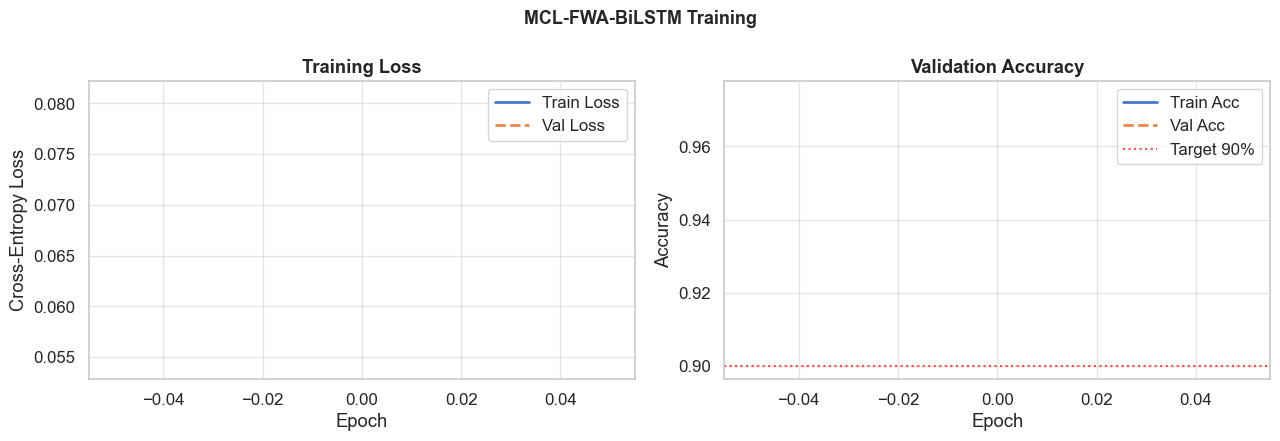

In [27]:
hist_df = pd.DataFrame(hist)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss', linewidth=2)
if 'val_loss' in hist_df:
    ax1.plot(hist_df['epoch'], hist_df['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
ax1.set_title('Training Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss'); ax1.legend()

ax2.plot(hist_df['epoch'], hist_df['train_acc'], label='Train Acc', linewidth=2)
if 'val_acc' in hist_df:
    ax2.plot(hist_df['epoch'], hist_df['val_acc'], label='Val Acc', linewidth=2, linestyle='--')
ax2.axhline(0.90, color='red', linestyle=':', alpha=0.7, label='Target 90%')
ax2.set_title('Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()

plt.suptitle('MCL-FWA-BiLSTM Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.pdf', bbox_inches='tight', dpi=300)
plt.show()

### V2 — FWA Attention Weights (Spatial Row Significance)

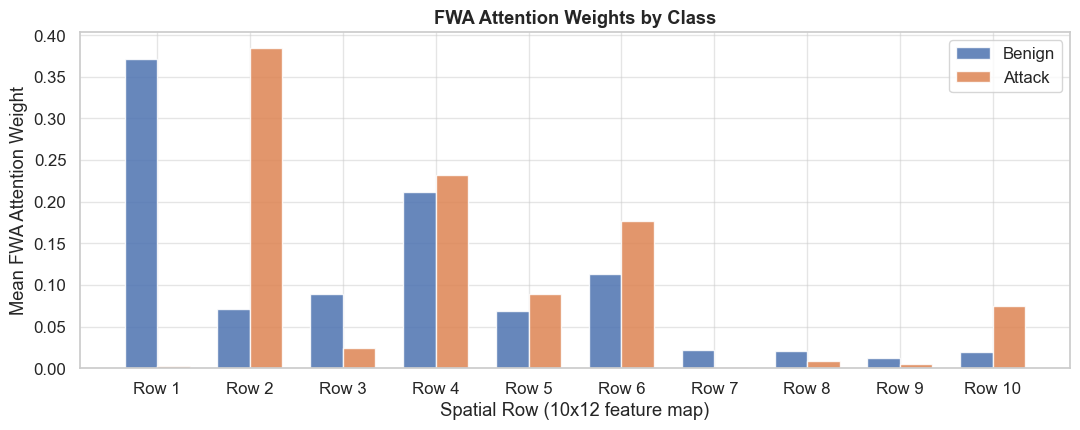

In [21]:
@torch.no_grad()
def get_attention_weights(extractor, X, device, batch_size=512):
    extractor.eval()
    all_fa = []
    for i in range(0, X.shape[0], batch_size):
        xb = X[i:i+batch_size].to(device, non_blocking=True)
        _, meta = extractor(xb)
        all_fa.append(meta['fa'].cpu())
    return torch.cat(all_fa, dim=0).numpy()  # (N, T=10)

fa_te     = get_attention_weights(extractor, X_te, cfg.device)
fa_benign = fa_te[y_bin_te.numpy() == 0].mean(axis=0)
fa_attack = fa_te[y_bin_te.numpy() == 1].mean(axis=0)

x_pos = np.arange(10); width = 0.35
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x_pos - width/2, fa_benign, width, label='Benign',  color='#4C72B0', alpha=0.85)
ax.bar(x_pos + width/2, fa_attack,  width, label='Attack', color='#DD8452', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels([f'Row {i+1}' for i in range(10)])
ax.set_xlabel('Spatial Row (10x12 feature map)')
ax.set_ylabel('Mean FWA Attention Weight')
ax.set_title('FWA Attention Weights by Class', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('fwa_attention.pdf', bbox_inches='tight', dpi=300)
plt.show()

### V3 — Classifier Comparison Bar Chart (Acc / Precision / Recall / F1)

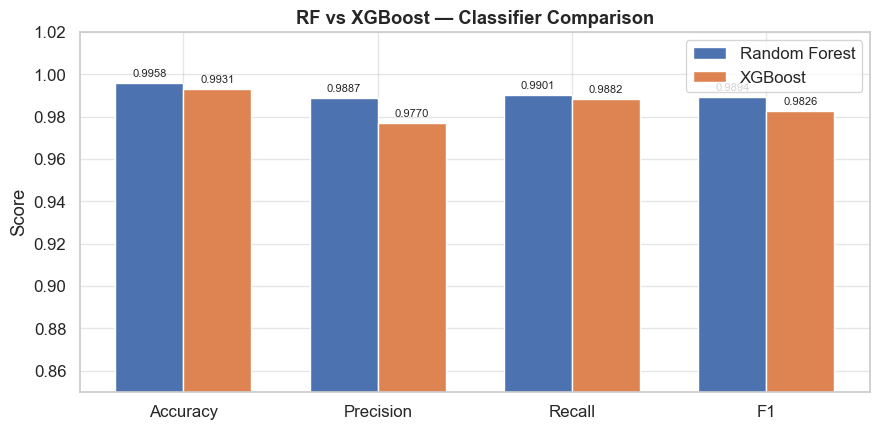

In [22]:
metrics_keys = ['accuracy', 'precision', 'recall', 'f1']
rf_vals  = [rf_metrics[k]  for k in metrics_keys]
xgb_vals = [xgb_metrics[k] for k in metrics_keys]
x = np.arange(len(metrics_keys)); width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))
bars_rf  = ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color=COLORS['RF'])
bars_xgb = ax.bar(x + width/2, xgb_vals, width, label='XGBoost',       color=COLORS['XGB'])
for bar in list(bars_rf) + list(bars_xgb):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002, f'{h:.4f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([m.capitalize() for m in metrics_keys])
ax.set_ylim(0.85, 1.02); ax.set_ylabel('Score')
ax.set_title('RF vs XGBoost — Classifier Comparison', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('classifier_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

### V4 — Confusion Matrices

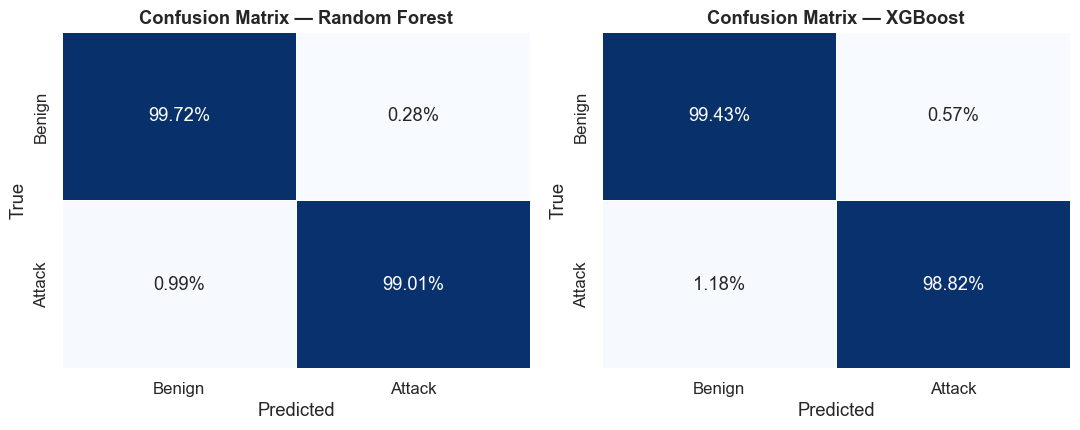

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
class_labels = ['Benign', 'Attack']

for ax, (name, metrics) in zip(axes, [
    ('Random Forest', rf_metrics),
    ('XGBoost',       xgb_metrics),
]):
    cm = np.array(metrics['confusion_matrix'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.pdf', bbox_inches='tight', dpi=300)
plt.show()

### V5 — ROC Curves with AUC

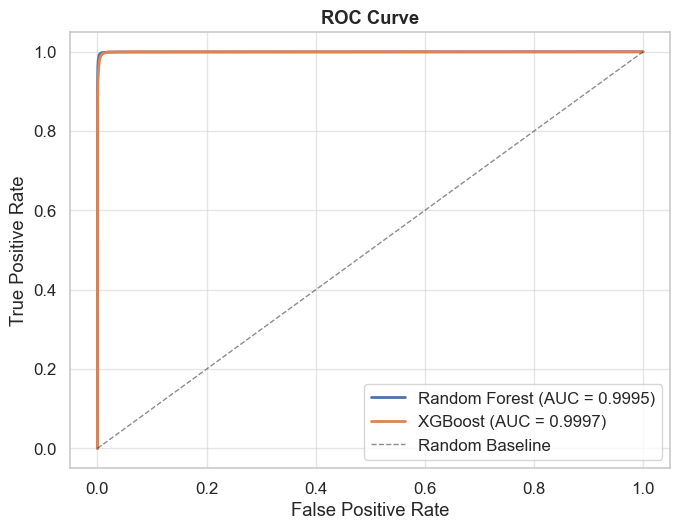

In [24]:
fig, ax = plt.subplots(figsize=(7, 5.5))
y_true = y_bin_te.numpy()

for name, clf, color in [
    ('Random Forest', rf_clf,  COLORS['RF']),
    ('XGBoost',       xgb_clf, COLORS['XGB']),
]:
    probs = clf.predict_proba(fe_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random Baseline')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right'); plt.tight_layout()
plt.savefig('roc_curve.pdf', bbox_inches='tight', dpi=300)
plt.show()

### V6 — Precision-Recall Curves

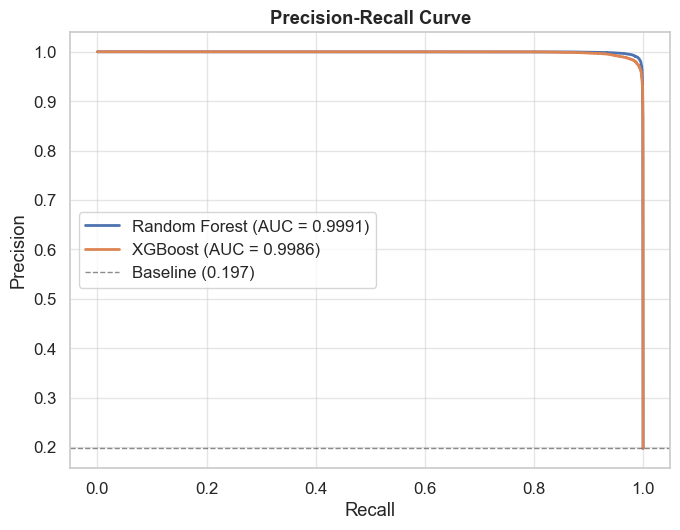

In [25]:
fig, ax = plt.subplots(figsize=(7, 5.5))

for name, clf, color in [
    ('Random Forest', rf_clf,  COLORS['RF']),
    ('XGBoost',       xgb_clf, COLORS['XGB']),
]:
    probs = clf.predict_proba(fe_te)[:, 1]
    prec, rec, _ = precision_recall_curve(y_true, probs)
    pr_auc = auc(rec, prec)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AUC = {pr_auc:.4f})')

baseline = y_true.mean()
ax.axhline(baseline, color='k', linestyle='--', lw=1, alpha=0.5, label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('pr_curve.pdf', bbox_inches='tight', dpi=300)
plt.show()

### V7 — t-SNE of DL-Extracted Feature Space

Running t-SNE on 5000 test samples...


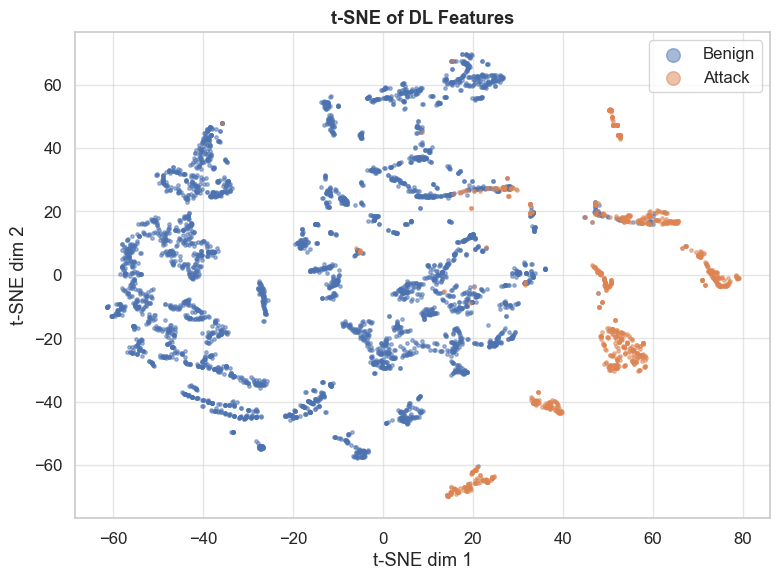

In [26]:
N_TSNE = min(5000, len(fe_te))
rng = np.random.default_rng(42)
idx = rng.choice(len(fe_te), N_TSNE, replace=False)
print(f'Running t-SNE on {N_TSNE} test samples...')
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
emb  = tsne.fit_transform(fe_te[idx])

labels_sub = y_bin_te.numpy()[idx]
fig, ax = plt.subplots(figsize=(8, 6))
for cls, name, color in [(0, 'Benign', '#4C72B0'), (1, 'Attack', '#DD8452')]:
    mask = labels_sub == cls
    ax.scatter(emb[mask, 0], emb[mask, 1], s=6, alpha=0.5, color=color, label=name)
ax.set_title('t-SNE of DL Features', fontweight='bold')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.legend(markerscale=4); plt.tight_layout()
plt.savefig('tsne.pdf', bbox_inches='tight', dpi=300)
plt.show()